# Severstal 钢板缺陷 EDA

本 Notebook 只覆盖已批准的四项工作：标签频率、标签共现、样本可视化和稀有标签分析。原始比赛数据保持只读；所有随机抽样使用配置中的固定种子。

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import Image, Markdown, display
from severstal_eda.cli import run_eda

START_DIR = Path.cwd().resolve()
REPO_ROOT = START_DIR if (START_DIR / 'config' / 'eda_config.yaml').is_file() else START_DIR.parent
LOCAL_CONFIG = REPO_ROOT / 'config' / 'eda_config.local.yaml'
CONFIG_PATH = LOCAL_CONFIG if LOCAL_CONFIG.is_file() else REPO_ROOT / 'config' / 'eda_config.yaml'
assert CONFIG_PATH.is_file(), f'Config not found: {CONFIG_PATH}'

## 1. 执行同一套受审计分析流程

In [2]:
result = run_eda(CONFIG_PATH)
summary = result.summary
display(pd.Series({
    '训练图片': summary['train_images'],
    '测试图片': summary['test_images'],
    '有缺陷图片': summary['defective_images'],
    '无缺陷图片': summary['no_defect_images'],
    '多标签图片': summary['multilabel_images'],
    '随机种子': summary['seed'],
}, name='运行汇总'))

训练图片     12568
测试图片      5506
有缺陷图片     6666
无缺陷图片     5902
多标签图片      427
随机种子        42
Name: 运行汇总, dtype: int64

## 2. 标签频率

,label,image_count,image_fraction
0,class_1,897,7.14%
1,class_2,247,1.97%
2,class_3,"5,150",40.98%
3,class_4,801,6.37%
4,no_defect,"5,902",46.96%


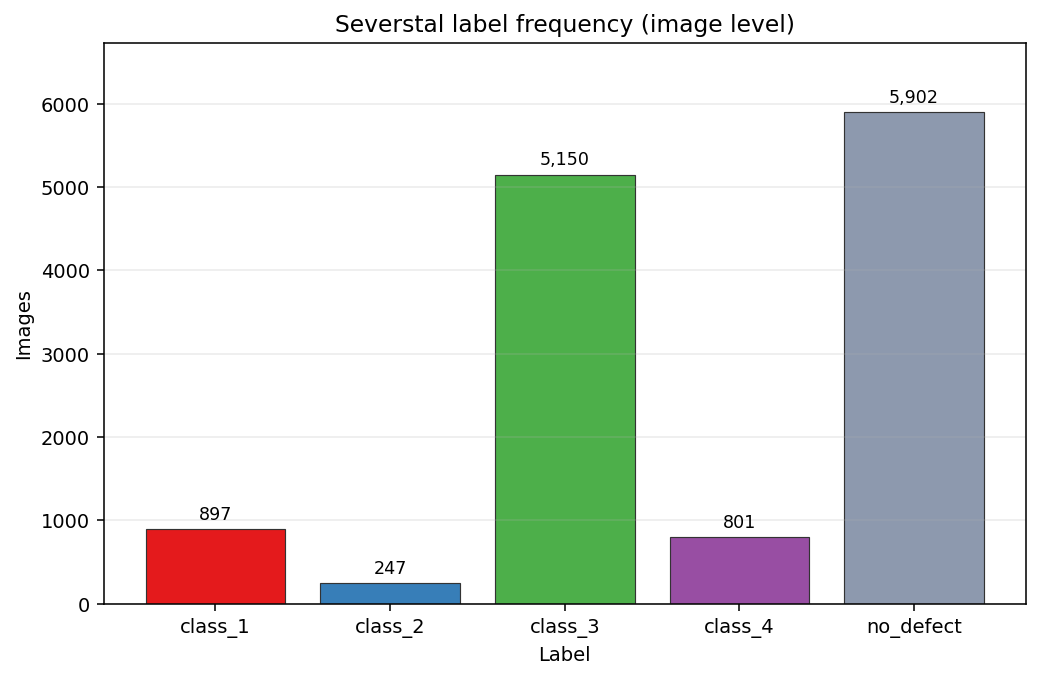

In [3]:
frequency = pd.read_csv(REPO_ROOT / 'outputs' / 'tables' / 'label_frequency.csv')
display(frequency.style.format({'image_count': '{:,}', 'image_fraction': '{:.2%}'}))
display(Image(filename=str(REPO_ROOT / 'outputs' / 'figures' / 'label_frequency.png')))

## 3. 精确标签组合与共现

,combination,image_count,image_fraction
0,none,"5,902",46.961%
1,3,"4,759",37.866%
2,1,769,6.119%
3,4,516,4.106%
4,3+4,284,2.260%
5,2,195,1.552%
6,1+3,91,0.724%
7,1+2,35,0.278%
8,2+3,14,0.111%
9,1+2+3,2,0.016%


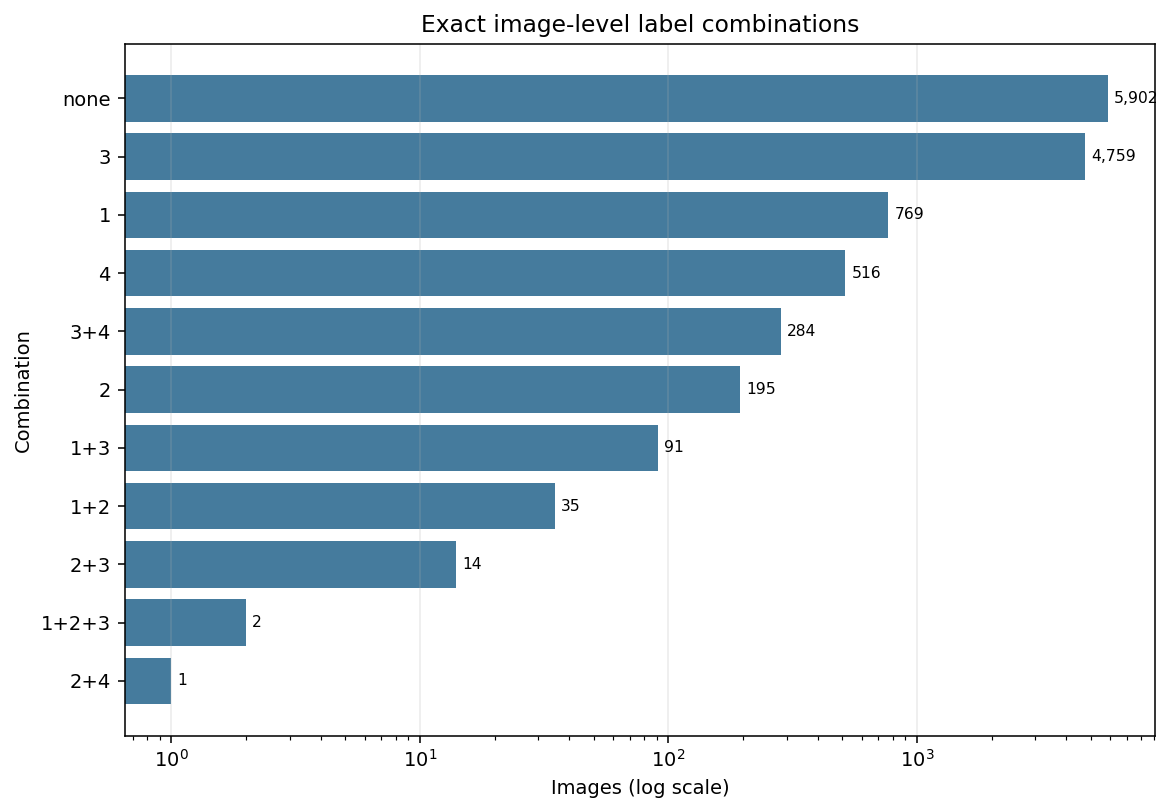

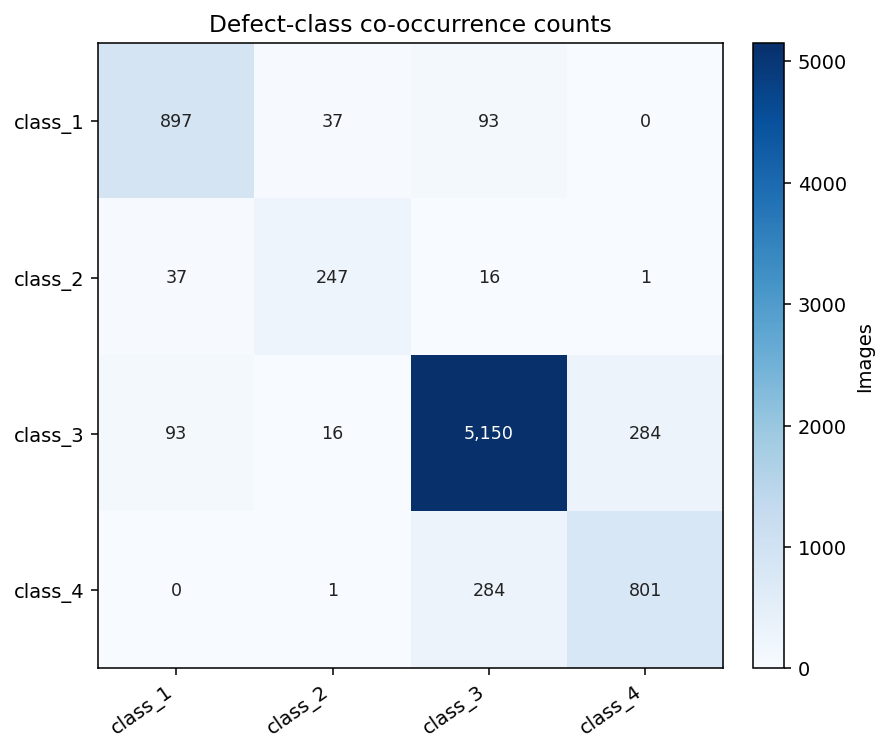

In [4]:
combinations = pd.read_csv(REPO_ROOT / 'outputs' / 'tables' / 'label_combinations.csv')
display(combinations.style.format({'image_count': '{:,}', 'image_fraction': '{:.3%}'}))
display(Image(filename=str(REPO_ROOT / 'outputs' / 'figures' / 'label_combinations.png')))
display(Image(filename=str(REPO_ROOT / 'outputs' / 'figures' / 'cooccurrence_heatmap.png')))

## 4. 代表性样本与稀有标签样本

叠加颜色由 `config/eda_config.yaml` 固定；标题记录图片 ID 和精确类别组合。

,group,ImageId
0,representative,83476e834.jpg
1,representative,b34091037.jpg
2,representative,eb3f5c9c8.jpg
3,representative,7ff9e795d.jpg
4,representative,f6db0a2e8.jpg
5,representative,c63e60886.jpg
6,rare,739a0aa20.jpg
7,rare,79c106c42.jpg
8,rare,ac6367260.jpg
9,rare,ef24da2ba.jpg


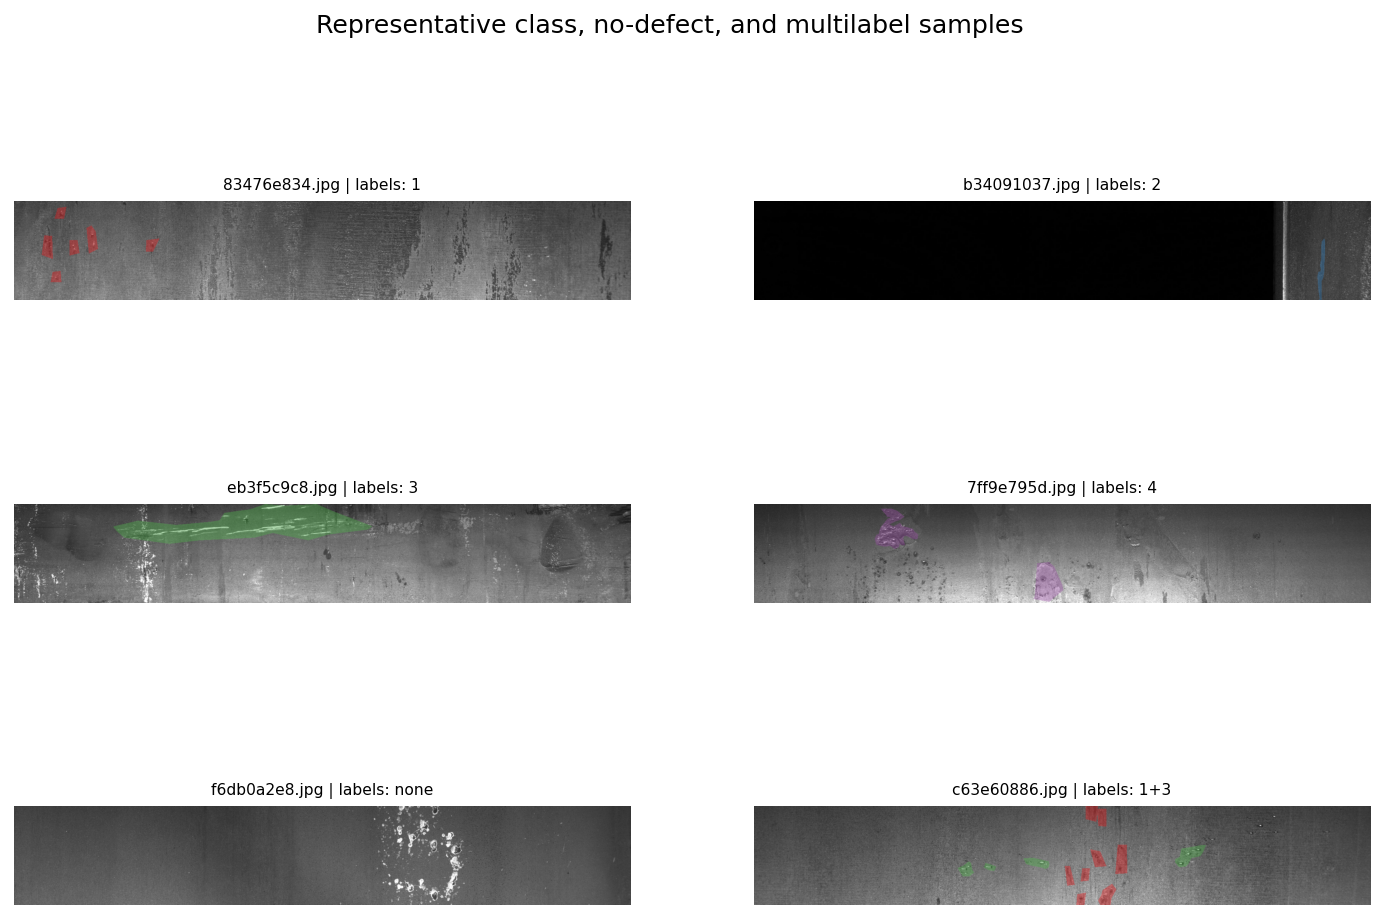

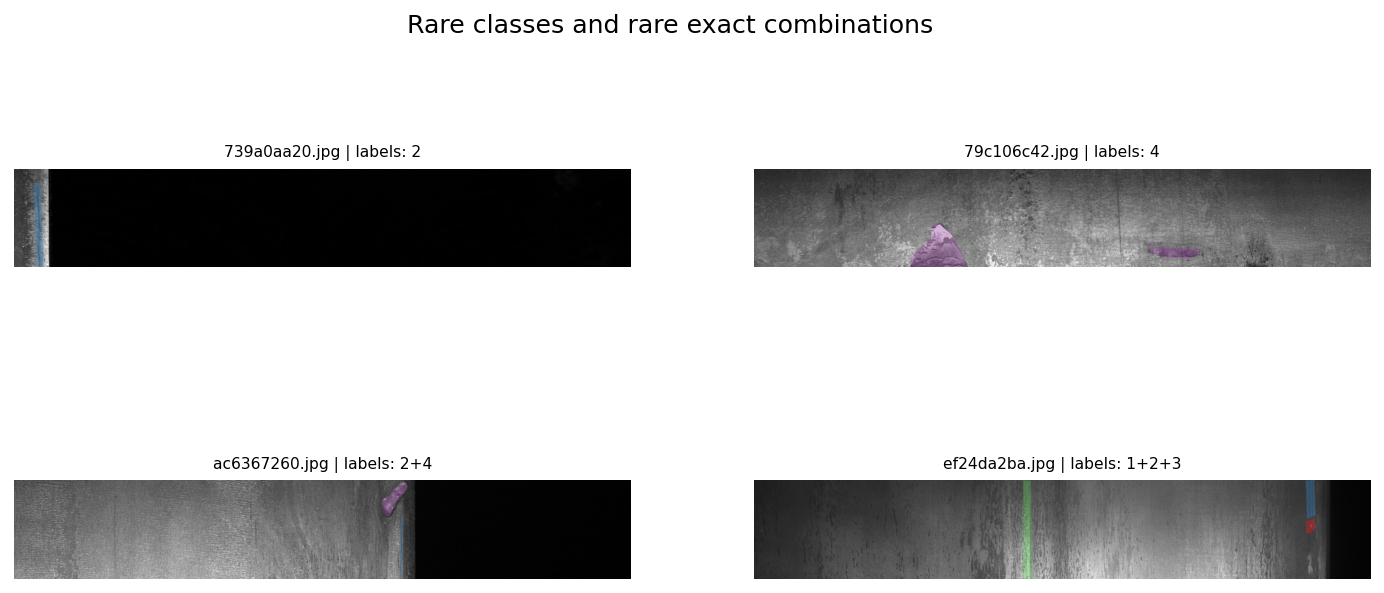

In [5]:
selected = pd.read_csv(REPO_ROOT / 'outputs' / 'tables' / 'selected_samples.csv')
display(selected)
display(Image(filename=str(REPO_ROOT / 'outputs' / 'figures' / 'representative_samples.png')))
display(Image(filename=str(REPO_ROOT / 'outputs' / 'figures' / 'rare_label_samples.png')))

## 5. 稀有标签与掩码面积

In [6]:
rare_classes = pd.read_csv(REPO_ROOT / 'outputs' / 'tables' / 'rare_classes.csv')
rare_combinations = pd.read_csv(REPO_ROOT / 'outputs' / 'tables' / 'rare_combinations.csv')
area = pd.read_csv(REPO_ROOT / 'outputs' / 'tables' / 'mask_area_statistics.csv')
display(Markdown('### 稀有类别'))
display(rare_classes.style.format({'image_count': '{:,}', 'image_fraction': '{:.3%}'}))
display(Markdown('### 稀有正标签组合'))
display(rare_combinations.style.format({'image_count': '{:,}', 'image_fraction': '{:.4%}'}))
display(Markdown('### 掩码面积分布'))
display(area)

### 稀有类别

,label,image_count,image_fraction
0,class_2,247,1.965%
1,class_4,801,6.373%
2,class_1,897,7.137%
3,class_3,"5,150",40.977%


### 稀有正标签组合

,combination,image_count,image_fraction
0,2+4,1,0.0080%
1,1+2+3,2,0.0159%
2,2+3,14,0.1114%
3,1+2,35,0.2785%
4,1+3,91,0.7241%
5,2,195,1.5516%
6,3+4,284,2.2597%
7,4,516,4.1057%
8,1,769,6.1187%
9,3,"4,759",37.8660%


### 掩码面积分布

,class_id,annotation_count,mean_pixels,minimum_pixels,q01_pixels,q05_pixels,q25_pixels,median_pixels,q75_pixels,q95_pixels,q99_pixels,maximum_pixels,mean_image_fraction,proportion_below_0_01pct,proportion_below_0_1pct,proportion_below_1pct
0,1,897,4361.347826,163.0,464.88,798.4,1762.00,3326.0,5795.0,11502.0,15666.92,31303.0,0.010648,0.0,0.007804,0.585284
1,2,247,3378.425101,316.0,574.50,989.3,1947.50,2944.0,4337.5,7138.4,10537.94,14023.0,0.008248,0.0,0.008097,0.720648
2,3,5150,25496.485243,115.0,719.90,1829.0,5054.25,11953.5,29029.5,94007.1,193331.38,368240.0,0.062247,0.0,0.004078,0.185631
3,4,801,34373.997503,491.0,1991.00,5115.0,13114.00,25357.0,45221.0,98530.0,129924.00,192780.0,0.083921,0.0,0.000000,0.034956


## 6. 溯源与完整报告

In [7]:
manifest_lines = (REPO_ROOT / 'MANIFEST.sha256').read_text(encoding='utf-8').splitlines()
display(pd.DataFrame({'SHA-256 manifest entry': manifest_lines}))
display(Markdown((REPO_ROOT / 'reports' / 'eda_report.md').read_text(encoding='utf-8')))

,SHA-256 manifest entry
0,e21d37041c3e5eea14da8d73f03dece22c25a62fa7d114...
1,ba3faa7c2acbc3372604fdf9f121142e1691df1fbe8292...
2,73b0ac935a216f0c84f479d8a466fd85aa7f365dfed96c...
3,4971780166a0619e911b5fa17ef0ff2a6506aef43437d3...
4,301cd4e70833967eea00018e17b722f4a5a2fa3f06891d...
5,96cf4dec18bc0bbf2e5b36485ced6fc65495dd74bd0a02...
6,ef960c20d224b3bc2c01343036927cd9332b2448d1df12...
7,a3058e055f558d14cfbf08036306aead83068dc31f2d63...
8,94ba2b9ef3dd6ae3a16213ab1bff454777ca61753a6d42...
9,63939b820b7931e4a4779c3c646bbd747c765354c0bc04...


# Severstal 钢板缺陷 EDA 报告

本报告仅覆盖已批准的四项内容：标签频率、标签共现、样本可视化和稀有标签分析。原始 Kaggle 数据保持只读；统计分母为训练图片清单中的全部 12,568 张图片。

## 关键结论

- 有缺陷图片 6,666 张，无缺陷图片 5,902 张；无缺陷比例为 46.96%。
- 最常见正类别是 `class_3`，共有 5,150 张（占全部训练图 40.98%）。
- 最稀有单类别是 `class_2`，共有 247 张（1.97%）。
- 最稀有的已出现正标签组合是 `2+4`，仅 1 张。
- 多标签图片共有 427 张。共现矩阵用于显示组合数量，条件矩阵另存为 CSV，避免把方向性条件概率误读为对称关系。

## 标签频率

| label | image_count | image_fraction |
| --- | --- | --- |
| class_1 | 897 | 0.071372 |
| class_2 | 247 | 0.019653 |
| class_3 | 5150 | 0.409771 |
| class_4 | 801 | 0.063733 |
| no_defect | 5902 | 0.469605 |

![标签频率](../outputs/figures/label_frequency.png)

## 精确标签组合

| combination | image_count | image_fraction |
| --- | --- | --- |
| none | 5902 | 0.469605 |
| 3 | 4759 | 0.378660 |
| 1 | 769 | 0.061187 |
| 4 | 516 | 0.041057 |
| 3+4 | 284 | 0.022597 |
| 2 | 195 | 0.015516 |
| 1+3 | 91 | 0.007241 |
| 1+2 | 35 | 0.002785 |
| 2+3 | 14 | 0.001114 |
| 1+2+3 | 2 | 0.000159 |
| 2+4 | 1 | 0.000080 |

![标签组合](../outputs/figures/label_combinations.png)

## 标签共现

| label | class_1 | class_2 | class_3 | class_4 |
| --- | --- | --- | --- | --- |
| class_1 | 897 | 37 | 93 | 0 |
| class_2 | 37 | 247 | 16 | 1 |
| class_3 | 93 | 16 | 5150 | 284 |
| class_4 | 0 | 1 | 284 | 801 |

![共现热图](../outputs/figures/cooccurrence_heatmap.png)

## 样本可视化

代表性样本固定使用种子 42，所选图片 ID 为：`83476e834.jpg, b34091037.jpg, eb3f5c9c8.jpg, 7ff9e795d.jpg, f6db0a2e8.jpg, c63e60886.jpg`。

![代表性样本](../outputs/figures/representative_samples.png)

## 稀有标签与微小掩码

稀有类别按图片数升序、标签名稳定排序；精确组合中的 `none` 不参与“稀有正标签组合”排名。掩码面积通过 RLE 长度直接求和，阈值比例相对于 256×1600 的图像面积计算。

| class_id | annotation_count | minimum_pixels | median_pixels | q95_pixels | maximum_pixels | proportion_below_1pct |
| --- | --- | --- | --- | --- | --- | --- |
| 1 | 897 | 163.000000 | 3326.000000 | 11502.000000 | 31303.000000 | 0.585284 |
| 2 | 247 | 316.000000 | 2944.000000 | 7138.400000 | 14023.000000 | 0.720648 |
| 3 | 5150 | 115.000000 | 11953.500000 | 94007.100000 | 368240.000000 | 0.185631 |
| 4 | 801 | 491.000000 | 25357.000000 | 98530.000000 | 192780.000000 | 0.034956 |

稀有样本 ID：`739a0aa20.jpg, 79c106c42.jpg, ac6367260.jpg, ef24da2ba.jpg`。

![稀有标签样本](../outputs/figures/rare_label_samples.png)

## 可复现性

- 配置：`config/eda_config.yaml`
- 随机种子：42
- 完整表格：`outputs/tables/`
- 运行摘要：`outputs/run_summary.json`
- 事件日志：`logs/eda_run.jsonl`
- SHA-256 清单：`MANIFEST.sha256`

本报告中的结论均来自本次执行生成的表格，不延伸到验证集划分、建模或提交策略。
